<a href="https://colab.research.google.com/github/ruvxn/Traffic-Guidance-System/blob/main/models/RNN_LSTM_GRU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import numpy as np
from sklearn.model_selection import train_test_split


X = np.load("/content/drive/MyDrive/Assignment2B/X_lstm_08.npy")
y = np.load("/content/drive/MyDrive/Assignment2B/y_lstm_08.npy")


X = X.reshape((X.shape[0], X.shape[1], 1))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"X shape: {X.shape}, y shape: {y.shape}")


X shape: (402112, 8, 1), y shape: (402112,)


# RNN MODEL

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam

rnn_model = Sequential()


rnn_model.add(SimpleRNN(units=64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
rnn_model.add(Dropout(0.2))


rnn_model.add(SimpleRNN(units=64, return_sequences=True))
rnn_model.add(Dropout(0.2))

rnn_model.add(SimpleRNN(units=32))
rnn_model.add(Dropout(0.2))


rnn_model.add(Dense(1))

rnn_model.compile(optimizer=Adam(), loss='mse', metrics=['mae'])




/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 34s 6ms/step - loss: 11785.0078 - mae: 75.2151 - val_loss: 3303.7983 - val_mae: 32.4165
Epoch 2/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 32s 4ms/step - loss: 2766.1831 - mae: 31.9603 - val_loss: 1392.8986 - val_mae: 21.0893
Epoch 3/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 43s 5ms/step - loss: 1671.4087 - mae: 27.4661 - val_loss: 1125.4939 - val_mae: 19.4960
Epoch 4/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 39s 4ms/step - loss: 1543.1495 - mae: 27.0902 - val_loss: 1104.1746 - val_mae: 19.5725
Epoch 5/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 40s 4ms/step - loss: 1449.0409 - mae: 26.2292 - val_loss: 1070.2371 - val_mae: 21.2145
Epoch 6/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - loss: 1416.2892 - mae: 25.6977 - val_loss: 985.5089 - val_mae: 18.9484
Epoch 7/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - loss: 1333.3853 - mae: 24.8358 - val_loss: 986.9673 - val_mae: 18.5742
Epoch 8/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - loss: 1299.8015 - mae: 24.3251 - val_loss

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

lstm_model = Sequential()
lstm_model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
lstm_model.add(Dropout(0.2))
lstm_model.add(LSTM(units=64, return_sequences=True))
lstm_model.add(Dropout(0.2))
lstm_model.add(LSTM(units=32))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer=Adam(), loss='mse', metrics=['mae'])

lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)


Epoch 1/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 50s 9ms/step - loss: 11364.6299 - mae: 72.9528 - val_loss: 3114.8647 - val_mae: 30.6328
Epoch 2/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 46s 9ms/step - loss: 2505.8662 - mae: 27.9675 - val_loss: 1229.3848 - val_mae: 19.3604
Epoch 3/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 81s 9ms/step - loss: 1278.2119 - mae: 20.9833 - val_loss: 927.0535 - val_mae: 17.6150
Epoch 4/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 47s 9ms/step - loss: 1041.7952 - mae: 19.5918 - val_loss: 889.2494 - val_mae: 17.6494
Epoch 5/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 81s 9ms/step - loss: 988.3929 - mae: 19.2524 - val_loss: 805.0854 - val_mae: 16.7455
Epoch 6/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 82s 9ms/step - loss: 964.6359 - mae: 18.9309 - val_loss: 791.6735 - val_mae: 16.9019
Epoch 7/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 82s 9ms/step - loss: 934.8774 - mae: 18.6960 - val_loss: 811.8357 - val_mae: 16.7693
Epoch 8/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 82s 9ms/step - loss: 912.4118 - mae: 18.5555 - val_loss: 764.0

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

gru_model = Sequential()
gru_model.add(GRU(units=64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
gru_model.add(Dropout(0.2))
gru_model.add(GRU(units=64, return_sequences=True))
gru_model.add(Dropout(0.2))
gru_model.add(GRU(units=32))
gru_model.add(Dropout(0.2))
gru_model.add(Dense(1))

gru_model.compile(optimizer=Adam(), loss='mse', metrics=['mae'])

gru_history = gru_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 48s 9ms/step - loss: 11444.3594 - mae: 73.3908 - val_loss: 3144.7903 - val_mae: 31.0176
Epoch 2/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 45s 9ms/step - loss: 2555.4199 - mae: 28.5246 - val_loss: 1254.3969 - val_mae: 19.6382
Epoch 3/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 44s 9ms/step - loss: 1302.7429 - mae: 21.5801 - val_loss: 929.9436 - val_mae: 17.7663
Epoch 4/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 82s 9ms/step - loss: 1080.6991 - mae: 20.1476 - val_loss: 830.6317 - val_mae: 16.8459
Epoch 5/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 82s 9ms/step - loss: 1011.7102 - mae: 19.6594 - val_loss: 801.4814 - val_mae: 16.4407
Epoch 6/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 82s 9ms/step - loss: 976.3960 - mae: 19.4279 - val_loss: 808.9915 - val_mae: 17.0113
Epoch 7/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 82s 9ms/step - loss: 964.6842 - mae: 19.2402 - val_loss: 787.7186 - val_mae: 16.4962
Epoch 8/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 45s 9ms/step - loss: 969.0973 - mae: 19.2624 - val_loss: 811.

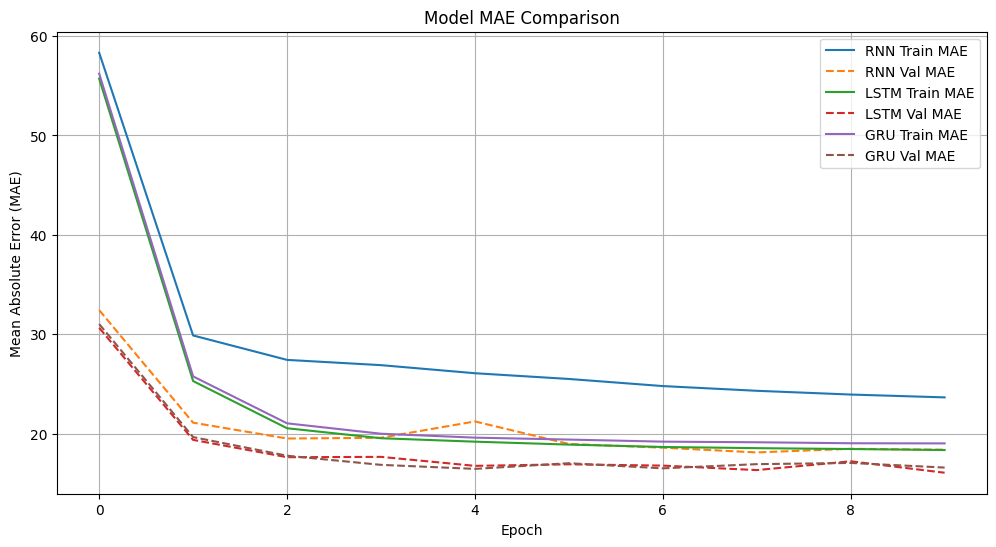

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))


plt.plot(rnn_history.history['mae'], label='RNN Train MAE', linestyle='-')
plt.plot(rnn_history.history['val_mae'], label='RNN Val MAE', linestyle='--')

plt.plot(lstm_history.history['mae'], label='LSTM Train MAE', linestyle='-')
plt.plot(lstm_history.history['val_mae'], label='LSTM Val MAE', linestyle='--')

plt.plot(gru_history.history['mae'], label='GRU Train MAE', linestyle='-')
plt.plot(gru_history.history['val_mae'], label='GRU Val MAE', linestyle='--')

plt.title('Model MAE Comparison')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend()
plt.grid(True)
plt.show()


In [15]:

y_pred_rnn = rnn_model.predict(X_test)
y_pred_lstm = lstm_model.predict(X_test)
y_pred_gru = gru_model.predict(X_test)




2514/2514 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2514/2514 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2514/2514 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


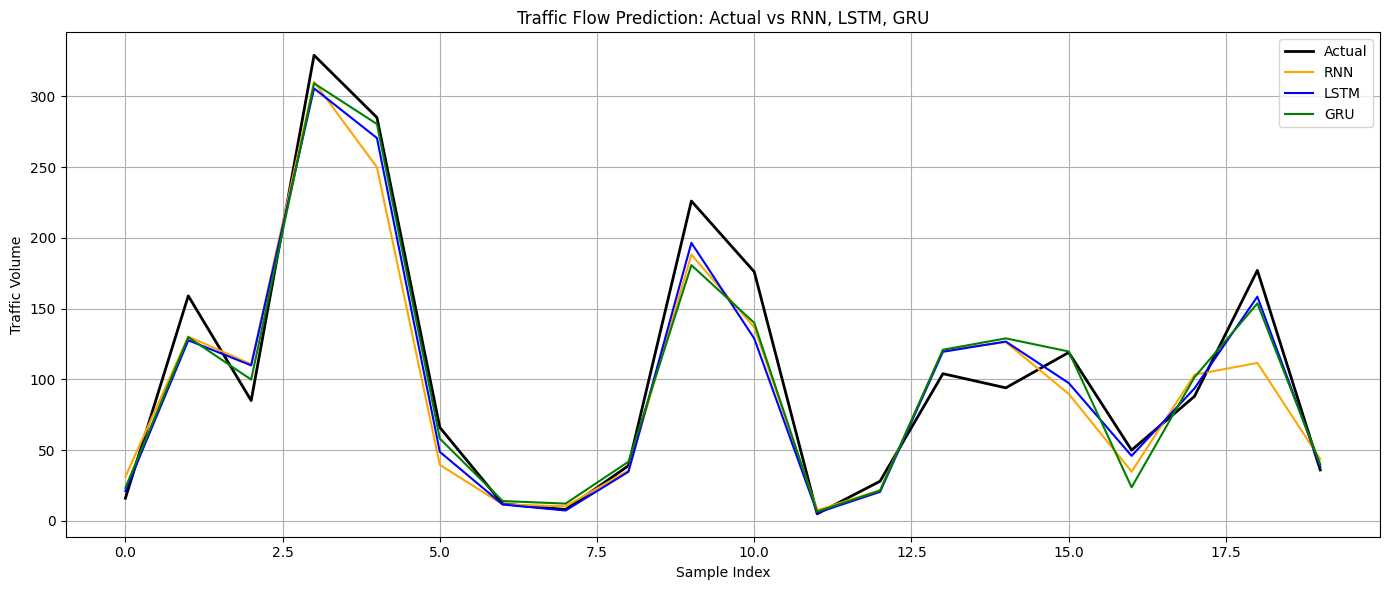

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Plot actual values
plt.plot(y_test[:20], label='Actual', color='black', linewidth=2)

# Plot predicted values from each model
plt.plot(y_pred_rnn[:20], label='RNN', color='orange', linestyle='-')
plt.plot(y_pred_lstm[:20], label='LSTM', color='blue', linestyle='-')
plt.plot(y_pred_gru[:20], label='GRU', color='green', linestyle='-')

plt.title('Traffic Flow Prediction: Actual vs RNN, LSTM, GRU')
plt.xlabel('Sample Index')
plt.ylabel('Traffic Volume')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


y_pred_rnn = rnn_model.predict(X_test).flatten()
y_pred_lstm = lstm_model.predict(X_test).flatten()
y_pred_gru = gru_model.predict(X_test).flatten()


y_true = y_test.flatten()


def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f" {name} Performance:")
    print(f"   MAE  : {mae:.4f}")
    print(f"   MSE  : {mse:.4f}")
    print(f"   RMSE : {rmse:.4f}")
    print(f"   R²   : {r2:.4f}\n")


evaluate_model("RNN", y_true, y_pred_rnn)
evaluate_model("LSTM", y_true, y_pred_lstm)
evaluate_model("GRU", y_true, y_pred_gru)


2514/2514 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2514/2514 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
2514/2514 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
 RNN Performance:
   MAE  : 18.3693
   MSE  : 933.3052
   RMSE : 30.5500
   R²   : 0.8754

 LSTM Performance:
   MAE  : 16.0543
   MSE  : 748.6702
   RMSE : 27.3618
   R²   : 0.9000

 GRU Performance:
   MAE  : 16.5735
   MSE  : 772.8516
   RMSE : 27.8002
   R²   : 0.8968



In [19]:
rnn_model.save("/content/rnn_model.h5")
lstm_model.save("/content/lstm_model.h5")
gru_model.save("/content/gru_model.h5")


In [21]:
from google.colab import files


files.download("/content/lstm_model.h5")
files.download("/content/gru_model.h5")
files.download("/content/rnn_model.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>